# Evaluate Model v2 — Stage 1 & Stage 2

Evaluate RT-DETR v2 models trained with two-stage strategy:
- **Stage 1**: Pre-trained on synthetic data (`kaya-go/moku-v2`, revision `stage1`)
- **Stage 2**: Fine-tuned on real data with LR sweep (`stage2-lr2e-4_run_3`, `stage2-lr5e-4_run_3`, `stage2-lr1e-3_run_3`)

**Sections:**
1. Load datasets and models (stage 1 + 3 stage 2 LR runs)
2. Compute mAP metrics (per stage/LR)
3. Side-by-side comparison table
4. Visualize predictions (best stage 2 vs stage 1 vs GT)

In [1]:
%load_ext autoreload
%autoreload 2

import matplotlib.pyplot as plt
import pandas as pd
import torch
from datasets import load_dataset
from transformers import RTDetrForObjectDetection, RTDetrImageProcessor

from moku.dataset import CATEGORIES, ID_TO_CATEGORY
from moku.training import (
    collate_fn,
    evaluate_center_distance,
    evaluate_map,
    format_center_distance_results,
    make_eval_transform,
)
from moku.viz import plot_map_comparison

/Users/hadim/Code/libs/moku/.pixi/envs/default/lib/python3.12/site-packages/albumentations/__init__.py:24: UserWarning: A new version of Albumentations is available: 2.0.8 (you have 1.4.20). Upgrade using: pip install -U albumentations. To disable automatic update checks, set the environment variable NO_ALBUMENTATIONS_UPDATE to 1.
  check_for_updates()


## Configuration

In [2]:
import re

from huggingface_hub import list_repo_refs

HF_MODEL = "kaya-go/moku-v2"
HF_DATASET = "kaya-go/moku-v2"
THRESHOLD = 0.05

# Dynamically discover stage2 branches from the HF model repo
refs = list_repo_refs(HF_MODEL)
STAGE2_RUNS = {}
for branch in refs.branches:
    m = re.match(r"stage2-lr([\de\-]+)_(run_\d+)", branch.name)
    if m:
        lr_str = m.group(1)
        run_id = m.group(2)
        label = f"lr={lr_str} ({run_id})"
        STAGE2_RUNS[label] = branch.name

print(f"Discovered {len(STAGE2_RUNS)} stage 2 branches:")
for label, rev in sorted(STAGE2_RUNS.items()):
    print(f"  {label} → {rev}")

device = "mps" if torch.backends.mps.is_available() else "cuda" if torch.cuda.is_available() else "cpu"
print(f"\nDevice: {device}")

Discovered 4 stage 2 branches:
  lr=1e-4 (run_2) → stage2-lr1e-4_run_2
  lr=2e-4 (run_2) → stage2-lr2e-4_run_2
  lr=5e-5 (run_2) → stage2-lr5e-5_run_2
  lr=8e-5 (run_2) → stage2-lr8e-5_run_2

Device: mps


## Load Datasets

In [3]:
# Synthetic dataset (stage 1 eval)
ds_synthetic = load_dataset(HF_DATASET, "synthetic")

# Real dataset (stage 2 eval)
ds_real = load_dataset(HF_DATASET, "real")

## Load Models

Stage 1 from branch `stage1`, Stage 2 from per-LR branches.

In [4]:
def _load_model(revision: str):
    ip = RTDetrImageProcessor.from_pretrained(HF_MODEL, revision=revision)
    model = RTDetrForObjectDetection.from_pretrained(
        HF_MODEL,
        revision=revision,
        num_labels=len(CATEGORIES),
        id2label=ID_TO_CATEGORY,
        label2id=CATEGORIES,
    )
    return ip, model

# Stage 1
print("Stage 1:")
ip_stage1, model_stage1 = _load_model("stage1")

# Stage 2 LR sweep
stage2_models = {}
for label, revision in STAGE2_RUNS.items():
    print(f"Stage 2 ({label}):")
    try:
        ip, model = _load_model(revision)
        stage2_models[label] = {"ip": ip, "model": model, "revision": revision}
    except Exception as e:
        print(f"  ⚠ Not found (not trained yet?): {e}")

Stage 1:


Loading weights:   0%|          | 0/526 [00:00<?, ?it/s]

Stage 2 (lr=5e-5 (run_2)):


Loading weights:   0%|          | 0/526 [00:00<?, ?it/s]

Stage 2 (lr=1e-4 (run_2)):


Loading weights:   0%|          | 0/526 [00:00<?, ?it/s]

Stage 2 (lr=8e-5 (run_2)):


Loading weights:   0%|          | 0/526 [00:00<?, ?it/s]

Stage 2 (lr=2e-4 (run_2)):


Loading weights:   0%|          | 0/526 [00:00<?, ?it/s]

## Stage 1 — mAP on Synthetic Validation & Real Test

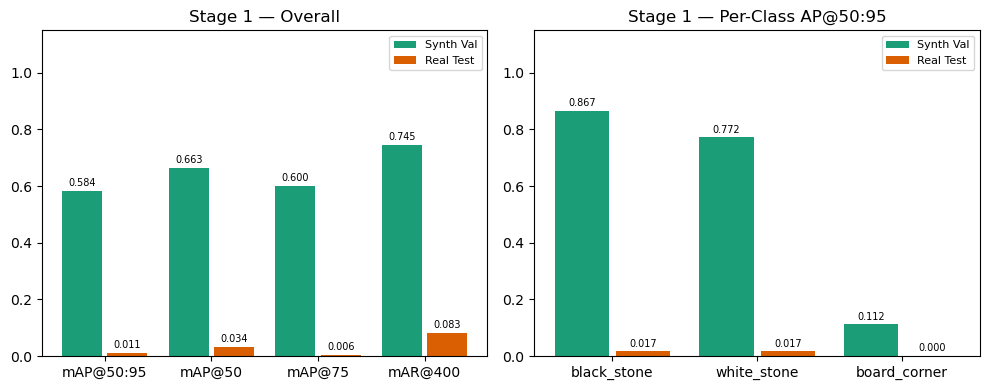

In [5]:
# --- Synthetic Validation ---
ds_synthetic.set_transform(make_eval_transform(ip_stage1))
metrics_s1_synth = evaluate_map(
    model=model_stage1,
    dataset=ds_synthetic["validation"],
    image_processor=ip_stage1,
    batch_size=8,
    threshold=THRESHOLD,
)

# --- Real Test ---
ds_real.set_transform(make_eval_transform(ip_stage1))
metrics_s1_real = evaluate_map(
    model=model_stage1,
    dataset=ds_real["test"],
    image_processor=ip_stage1,
    batch_size=8,
    threshold=THRESHOLD,
)

plot_map_comparison(
    {"Synth Val": metrics_s1_synth, "Real Test": metrics_s1_real},
    title="Stage 1",
)

## Stage 2 — mAP on Real Test (all LR runs)

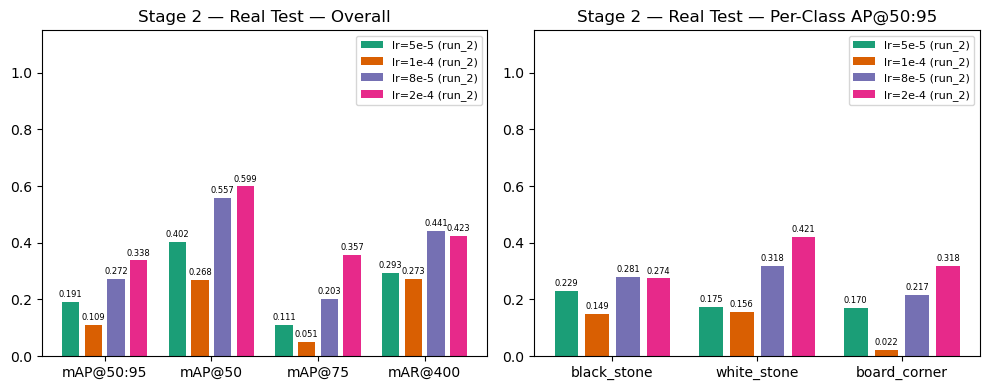

In [6]:
metrics_s2 = {}

if not stage2_models:
    print("No stage 2 models available yet — skipping.")
else:
    for label, entry in stage2_models.items():
        ds_real.set_transform(make_eval_transform(entry["ip"]))
        metrics_s2[label] = evaluate_map(
            model=entry["model"],
            dataset=ds_real["test"],
            image_processor=entry["ip"],
            batch_size=8,
            threshold=THRESHOLD,
        )

    plot_map_comparison(metrics_s2, title="Stage 2 — Real Test")

## Browse Predictions

Interactive widget to browse model predictions on dataset samples.

In [8]:
from moku.viz import browse_predictions

# Build model registry
all_models = {"Stage 1 (synthetic)": {"model": model_stage1.to(device), "image_processor": ip_stage1}}
for label, entry in stage2_models.items():
    all_models[f"Stage 2 ({label})"] = {"model": entry["model"].to(device), "image_processor": entry["ip"]}

# Build dataset registry
all_datasets = {"Real": ds_real, "Synthetic": ds_synthetic}

browse_predictions(all_models, all_datasets, threshold=THRESHOLD)

## Center-Distance Evaluation

mAP penalizes bbox size mismatches, but for our use case only the **center point** matters:
- **board_corner**: center → homography point
- **stones**: center → snap to nearest grid intersection

The center-distance metric reports Precision/Recall/F1 at various distance thresholds
(as % of image diagonal). A detection is "correct" if its center is within X% of the
diagonal from the nearest GT center of the same class.

In [8]:
# Stage 1 → Synthetic Validation (center-distance)
ds_synthetic.set_transform(make_eval_transform(ip_stage1))
cd_s1_synth = evaluate_center_distance(
    model=model_stage1,
    dataset=ds_synthetic["validation"],
    image_processor=ip_stage1,
    batch_size=8,
    threshold=THRESHOLD,
)
print("=== Stage 1 — Synthetic Validation (Center Distance) ===")
display(format_center_distance_results(cd_s1_synth))

# Stage 1 → Real Test (center-distance)
ds_real.set_transform(make_eval_transform(ip_stage1))
cd_s1_real = evaluate_center_distance(
    model=model_stage1,
    dataset=ds_real["test"],
    image_processor=ip_stage1,
    batch_size=8,
    threshold=THRESHOLD,
)
print("\n=== Stage 1 — Real Test (Center Distance) ===")
display(format_center_distance_results(cd_s1_real))

# Stage 2 runs (center-distance)
cd_s2 = {}
for label, entry in stage2_models.items():
    ds_real.set_transform(make_eval_transform(entry["ip"]))
    cd = evaluate_center_distance(
        model=entry["model"],
        dataset=ds_real["test"],
        image_processor=entry["ip"],
        batch_size=8,
        threshold=THRESHOLD,
    )
    cd_s2[label] = cd
    print(f"\n=== Stage 2 ({label}) — Real Test (Center Distance) ===")
    display(format_center_distance_results(cd))

=== Stage 1 — Synthetic Validation (Center Distance) ===


,category,n_gt,n_pred,matched,mean_dist_px,median_dist_px,P@1%,R@1%,F1@1%,P@2%,R@2%,F1@2%,P@5%,R@5%,F1@5%
0,black_stone,4550,4761,4377,2.51,0.30,0.9021,0.9440,0.9226,0.9021,0.9440,0.9226,0.9044,0.9464,0.9249
1,white_stone,4706,4004,3940,3.11,0.25,0.9643,0.8204,0.8866,0.9643,0.8204,0.8866,0.9675,0.8232,0.8896
2,board_corner,252,2025,234,16.27,0.95,0.1086,0.8730,0.1932,0.1086,0.8730,0.1932,0.1096,0.8810,0.1950



=== Stage 1 — Real Test (Center Distance) ===


,category,n_gt,n_pred,matched,mean_dist_px,median_dist_px,P@1%,R@1%,F1@1%,P@2%,R@2%,F1@2%,P@5%,R@5%,F1@5%
0,black_stone,253,297,240,27.84,6.42,0.4242,0.4980,0.4582,0.4983,0.5850,0.5382,0.6397,0.7510,0.6909
1,white_stone,223,750,223,5.33,0.98,0.2560,0.8610,0.3947,0.2733,0.9193,0.4214,0.2907,0.9776,0.4481
2,board_corner,28,323,27,89.56,55.61,0.0124,0.1429,0.0228,0.0279,0.3214,0.0513,0.0372,0.4286,0.0684



=== Stage 2 (lr=5e-5) — Real Test (Center Distance) ===


...

,category,n_gt,n_pred,matched,mean_dist_px,median_dist_px,P@1%,R@1%,F1@1%,P@2%,R@2%,F1@2%,P@5%,R@5%,F1@5%
0,black_stone,253,315,250,16.54,1.06,0.5841,0.7273,0.6479,0.6381,0.7945,0.7077,0.7016,0.8735,0.7782
1,white_stone,223,385,223,3.38,0.68,0.5403,0.9327,0.6842,0.5481,0.9462,0.6941,0.5636,0.9731,0.7138
2,board_corner,28,60,24,43.80,1.40,0.3000,0.6429,0.4091,0.3000,0.6429,0.4091,0.3000,0.6429,0.4091



=== Stage 2 (lr=1e-4) — Real Test (Center Distance) ===


,category,n_gt,n_pred,matched,mean_dist_px,median_dist_px,P@1%,R@1%,F1@1%,P@2%,R@2%,F1@2%,P@5%,R@5%,F1@5%
0,black_stone,253,341,251,22.04,1.01,0.5337,0.7194,0.6128,0.5806,0.7826,0.6667,0.6452,0.8696,0.7407
1,white_stone,223,300,212,16.27,0.89,0.4967,0.6682,0.5698,0.5533,0.7444,0.6348,0.6300,0.8475,0.7228
2,board_corner,28,131,24,68.54,14.90,0.0840,0.3929,0.1384,0.0916,0.4286,0.1509,0.1069,0.5000,0.1761



=== Stage 2 (lr=2e-4) — Real Test (Center Distance) ===


,category,n_gt,n_pred,matched,mean_dist_px,median_dist_px,P@1%,R@1%,F1@1%,P@2%,R@2%,F1@2%,P@5%,R@5%,F1@5%
0,black_stone,253,155,155,20.13,0.81,0.8387,0.5138,0.6373,0.8581,0.5257,0.6520,0.8839,0.5415,0.6716
1,white_stone,223,200,196,18.52,0.64,0.8150,0.7309,0.7707,0.8300,0.7444,0.7849,0.9000,0.8072,0.8511
2,board_corner,28,58,23,54.36,1.37,0.3276,0.6786,0.4419,0.3276,0.6786,0.4419,0.3276,0.6786,0.4419
